In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load balanced training and test sets
X_train_res, y_train_res = joblib.load("X_train_balanced.pkl")
X_test, y_test           = joblib.load("X_test_balanced.pkl")
class_names              = joblib.load("class_names.pkl")

Train Random Forest with Class Weights

In [3]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_res), y=y_train_res)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

# Save model
joblib.dump(rf_model, "random_forest.pkl")
print("✅ Random Forest model trained and saved as random_forest.pkl")

✅ Random Forest model trained and saved as random_forest.pkl


Confusion Matrix

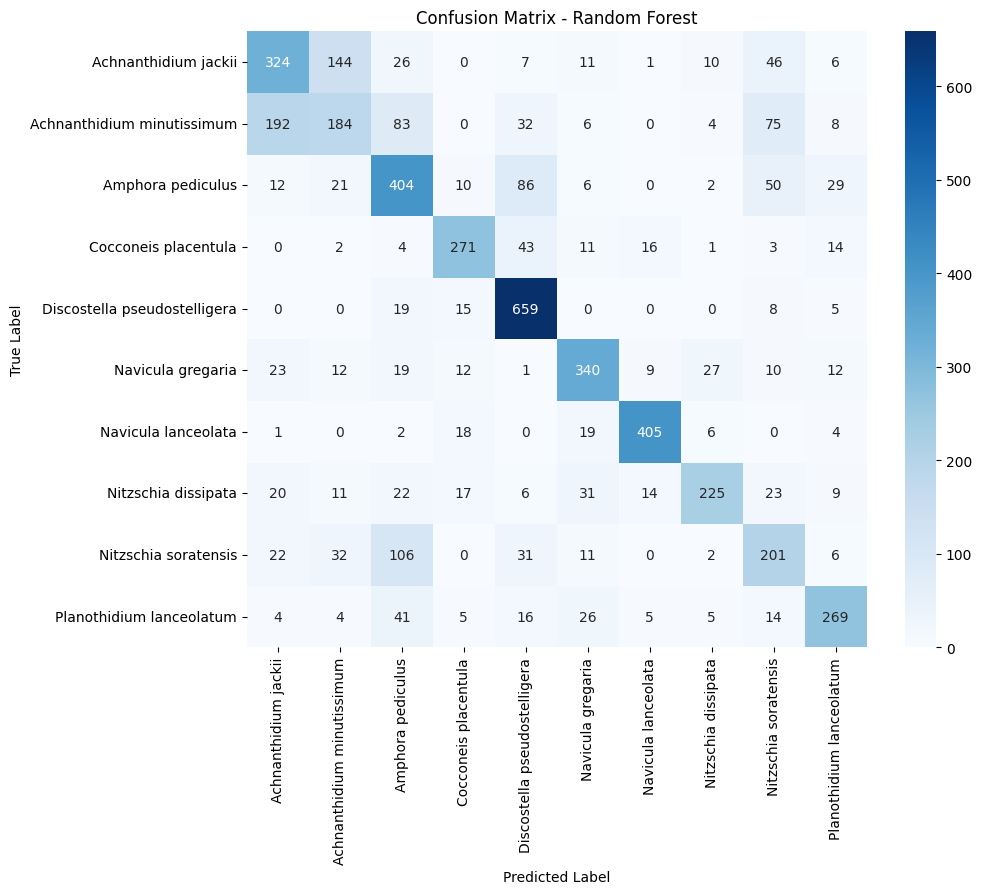

In [4]:
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Significance:
Shows per-class performance and misclassifications


ROC Curve

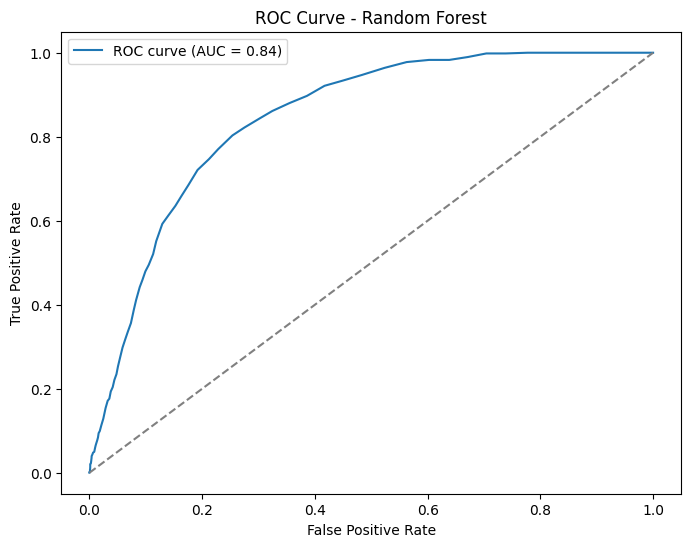

In [5]:
y_prob = rf_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Significance:
Evaluates sensitivity vs specificity


Precision-Recall Curve

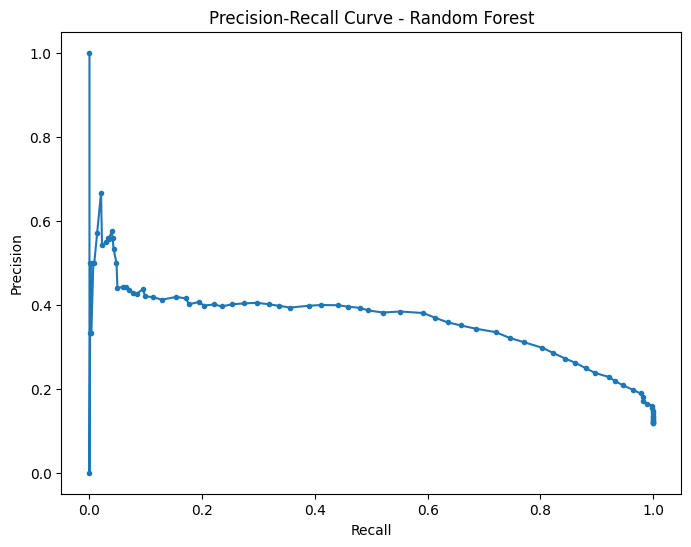

In [6]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:,1], pos_label=1)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

Significance:
Useful for imbalanced datasets, showing trade-off between precision and recall


Confidence Frequency Distribution

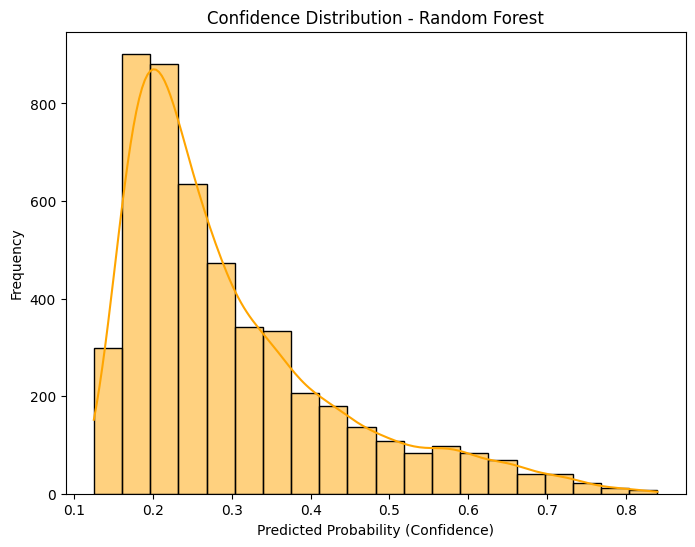

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(np.max(y_prob, axis=1), bins=20, kde=True, color="orange")
plt.xlabel("Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.title("Confidence Distribution - Random Forest")
plt.show()

Significance:
Shows how confident the model is in its predictions


Class-wise Accuracy

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_23856\2678687871.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_acc, palette="viridis")


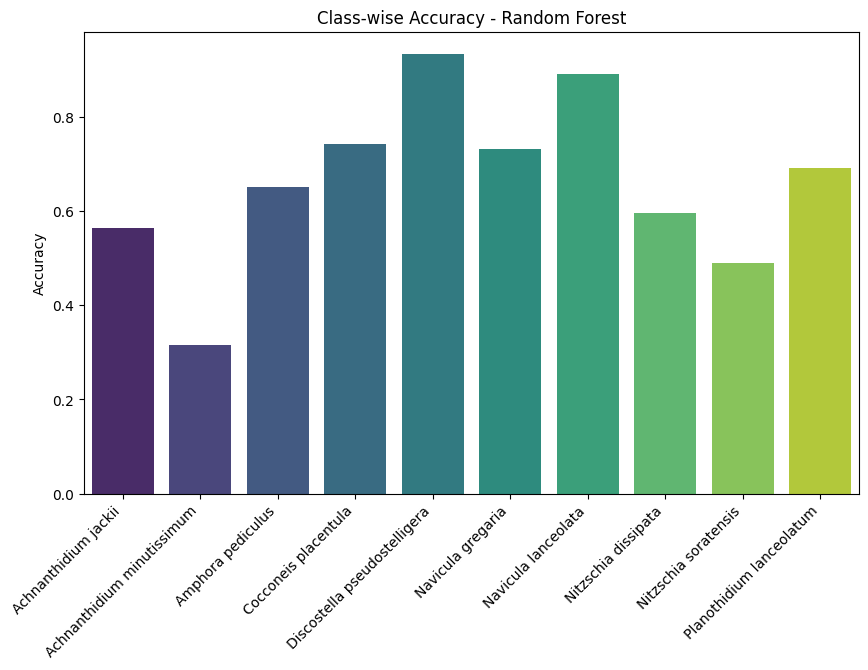

In [8]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
class_acc = [report[cls]['recall'] for cls in class_names]

plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_acc, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy - Random Forest")
plt.show()

Significance:
Highlights which species are classified well and which need improvement


Reliability Plot (Calibration Curve)

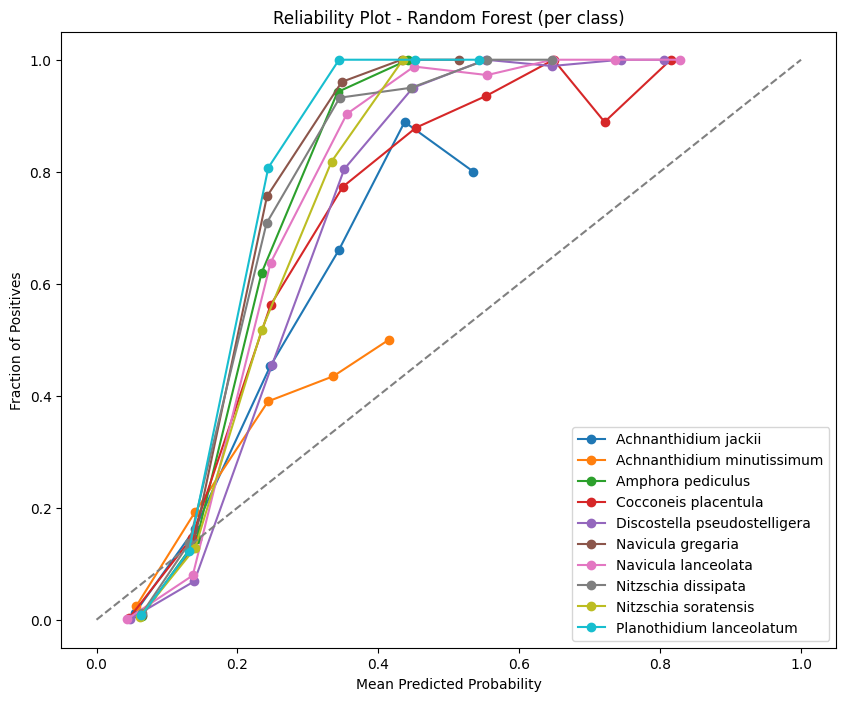

In [10]:
from sklearn.calibration import calibration_curve

y_prob = rf_model.predict_proba(X_test)

plt.figure(figsize=(10,8))
for i, cls in enumerate(class_names):
    # Binary labels: 1 if sample belongs to class i, else 0
    prob_true, prob_pred = calibration_curve(
        (y_test == i).astype(int),
        y_prob[:, i],
        n_bins=10
    )
    plt.plot(prob_pred, prob_true, marker='o', label=f"{cls}")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Plot - Random Forest (per class)")
plt.legend()
plt.show()

Significance:
Shows how well predicted probabilities match actual outcomes.


In [11]:
import joblib
from sklearn.metrics import classification_report, accuracy_score

# Load model and supporting data
rf_model     = joblib.load("random_forest.pkl")
X_test, y_test = joblib.load("X_test_balanced.pkl")
class_names  = joblib.load("class_names.pkl")

# Predict on test set
y_pred = rf_model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Random Forest Accuracy: 0.6633

Classification Report:
                              precision    recall  f1-score   support

        Achnanthidium jackii       0.54      0.56      0.55       575
  Achnanthidium minutissimum       0.45      0.32      0.37       584
           Amphora pediculus       0.56      0.65      0.60       620
        Cocconeis placentula       0.78      0.74      0.76       365
Discostella pseudostelligera       0.75      0.93      0.83       706
           Navicula gregaria       0.74      0.73      0.73       465
         Navicula lanceolata       0.90      0.89      0.90       455
         Nitzschia dissipata       0.80      0.60      0.68       378
        Nitzschia soratensis       0.47      0.49      0.48       411
    Planothidium lanceolatum       0.74      0.69      0.72       389

                    accuracy                           0.66      4948
                   macro avg       0.67      0.66      0.66      4948
                weighted avg     

- Random Forest trained with class weights for balanced learning.
- Evaluation suite: confusion matrix, ROC, PR curve, confidence distribution, class-wise accuracy, reliability plot.
- Model saved as random_forest.pkl.
